# 04 · MLP Classifier in PyTorch (framework component)

**Owner:** Riya (Model Lead)

```
Input (D_in = 40)
 → Linear(40, 64) → BatchNorm1d(64) → ReLU → Dropout(0.3)
 → Linear(64, 32) → BatchNorm1d(32) → ReLU → Dropout(0.3)
 → Linear(32, 1)  → Sigmoid                               → P(churn)
Loss: BCELoss · Optimiser: Adam(lr=1e-3, weight_decay=1e-4) · batch 64 · ≤150 epochs · early stopping (patience 10)
```

| Component | Purpose |
|---|---|
| **BatchNorm1d** | normalises each hidden unit over the mini-batch → stable activations, faster training, mild regularisation |
| **ReLU** | non-linearity whose gradient is 1 for positive inputs → no vanishing gradient |
| **Dropout(0.3)** | randomly zeroes 30 % of hidden units while training → prevents co-adaptation / over-fitting |
| **L2 weight decay 1e-4** | adds λ‖θ‖²/2 to the loss → keeps weights small |
| **Early stopping** | keeps the weights with the lowest validation loss; stops after 10 epochs without improvement |
| **Sigmoid output** | bounds the output to (0, 1) so it is a probability usable for cost-based thresholds |

In [1]:
# ── Environment setup: works on Google Colab (Drive) AND locally (VS Code / Jupyter) ──
import os, sys

try:
    from google.colab import drive  # only importable inside a Colab runtime
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/telco-churn-dashboard'
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    _cwd = os.path.abspath(os.getcwd())
    PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)                      # every relative path is now project-relative
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)        # lets us `import src...`
print('Project root:', PROJECT_ROOT, '| running on Colab:', IN_COLAB)

Project root: /Users/friday/Desktop/nndl/telco-churn-dashboard | running on Colab: False


In [2]:
# Colab already ships torch, numpy, pandas, scikit-learn, matplotlib and seaborn.
# Install the extras once per Colab session (skipped automatically when running locally).
if IN_COLAB:
    %pip install -q imbalanced-learn shap fastapi uvicorn jinja2 python-multipart joblib

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

from src import config
from src import plotting as P
from src.data_preprocessing import load_splits
from src.metrics import classification_metrics
from src.model import ChurnMLP, count_parameters, predict_proba, save_weights
from src.training import train_mlp

P.apply_style()
device = config.get_device()
splits = load_splits()                       # train + validation only
X_train, y_train, X_val, y_val = splits.X_train, splits.y_train, splits.X_val, splits.y_val
D_in = X_train.shape[1]
print('device:', device, '| D_in =', D_in)

device: cpu | D_in = 40


## 1 · Build the network
`config.set_seed(42)` is called **immediately before** constructing the model so the random initial weights are reproducible.

In [4]:
config.set_seed(config.SEED)
model = ChurnMLP(input_dim=D_in, hidden_dims=config.HIDDEN_DIMS, dropout=config.DROPOUT)
print(model)
print(f'\nTrainable parameters: {count_parameters(model):,}')
# 40*64+64 + 2*64 (BN γ,β) + 64*32+32 + 2*32 + 32*1+1 = 4,929

ChurnMLP(
  (backbone): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (head): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Trainable parameters: 4,929


## 2 · Train with Adam + L2 weight decay + early stopping
`drop_last=True` in the DataLoader: 4,225 rows / 64 leaves a final batch of **one** row, for which BatchNorm cannot compute a variance (PyTorch would raise an error). Because batches are reshuffled every epoch, a different row is skipped each time.

In [5]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

model, history = train_mlp(
    model, X_train, y_train, X_val, y_val, criterion,
    criterion_on_logits=False,              # BCELoss consumes probabilities (after Sigmoid)
    optimizer=optimizer,
    batch_size=config.BATCH_SIZE, max_epochs=config.MAX_EPOCHS, patience=config.PATIENCE,
    seed=config.SEED, device=device,
    checkpoint_path=config.MODELS_DIR / 'mlp_plain_bce.pth',
)
print(f'\nBest epoch {history.best_epoch} (val loss {history.best_val_loss:.4f}); '
      f'ran {history.epochs_run} epochs in {history.seconds:.1f}s')

# Provisional deployment weights — notebook 05 overwrites best_model.pth with the winning imbalance strategy.
save_weights(model, config.BEST_MODEL_PATH)
config.save_json(history.to_dict(), config.RESULTS_DIR / 'mlp_plain_bce_history.json')

epoch   1 | train loss 0.6040 | val loss 0.5048 | val PR-AUC 0.6145


epoch  10 | train loss 0.4153 | val loss 0.4386 | val PR-AUC 0.6261


epoch  20 | train loss 0.4070 | val loss 0.4347 | val PR-AUC 0.6281


epoch  30 | train loss 0.3913 | val loss 0.4375 | val PR-AUC 0.6290
Early stopping at epoch 31: no val-loss improvement for 10 epochs (best epoch 21).

Best epoch 21 (val loss 0.4342); ran 31 epochs in 1.1s


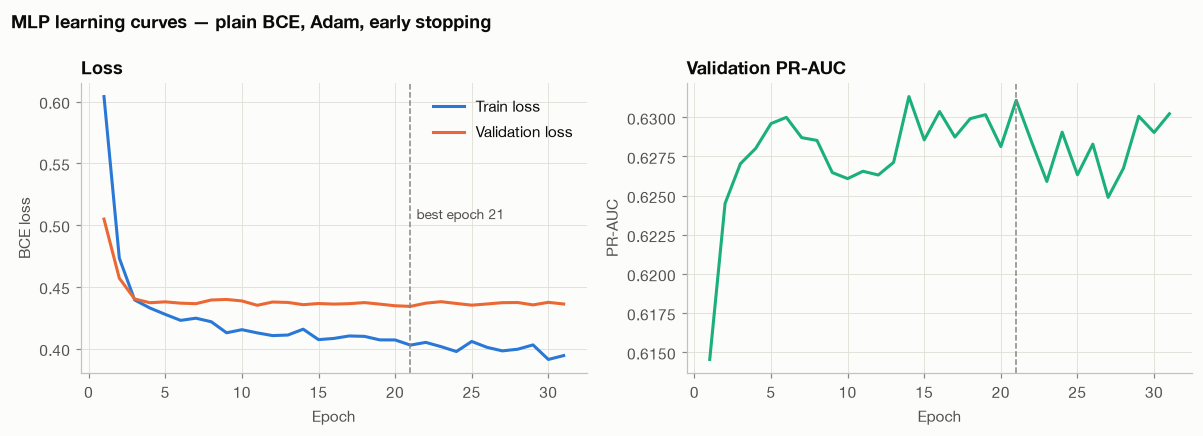

In [6]:
fig = P.plot_learning_curves(history, 'MLP learning curves — plain BCE, Adam, early stopping')
P.save_figure(fig, config.PLOTS_DIR / 'learning_curves.png')
plt.show()

**Reading the curves.** Training loss keeps falling while validation loss flattens and then drifts upwards — the onset of over-fitting. Early stopping restores the weights from the dashed line (lowest validation loss). Validation loss can sit *below* training loss in early epochs because training loss is measured with Dropout active (a handicapped network), whereas validation uses the full network in `eval()` mode.

In [7]:
val_prob = predict_proba(model, X_val, device=device)
mlp_metrics = classification_metrics(y_val, val_prob, threshold=0.5)
pd.Series(mlp_metrics).to_frame('MLP plain BCE (validation)').T.round(4)

,precision,recall,f1,pr_auc,roc_auc,accuracy,threshold,tp,fp,tn,fn,n_flagged
MLP plain BCE (validation),0.6411,0.5588,0.5971,0.6311,0.8317,0.7999,0.5,209.0,117.0,918.0,165.0,326.0


## 3 · Optimiser convergence comparison (Unit 1)
Identical architecture, **identical initial weights and batch order** (`set_seed(42)` before each run), identical L2 penalty, 30 epochs, no early stopping — only the update rule differs.

| Optimiser | Update rule |
|---|---|
| SGD + momentum | $v_t = \beta v_{t-1} + g_t,\;\; \theta \leftarrow \theta - \eta v_t$ (η = 0.01, β = 0.9) |
| RMSprop | $s_t = \rho s_{t-1} + (1-\rho) g_t^2,\;\; \theta \leftarrow \theta - \eta\, g_t / (\sqrt{s_t}+\epsilon)$ (η = 0.001) |
| Adam | $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t,\;\; v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$, bias-corrected $\hat m_t, \hat v_t$, $\theta \leftarrow \theta - \eta\, \hat m_t/(\sqrt{\hat v_t}+\epsilon)$ (η = 0.001) |

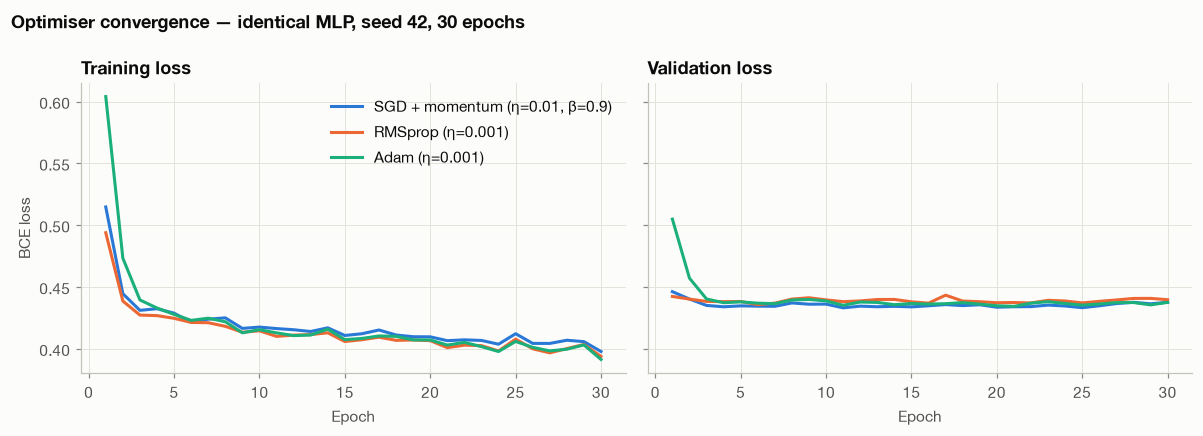

,train loss @ epoch 1,train loss @ epoch 5,train loss @ epoch 30,min val loss,epoch of min val loss,val PR-AUC @ epoch 30,"val-loss jitter (std of Δ, last 10)"
"SGD + momentum (η=0.01, β=0.9)",0.5146,0.4287,0.3977,0.4330,11.0,0.6248,0.0012
RMSprop (η=0.001),0.4938,0.4246,0.3937,0.4356,6.0,0.6273,0.0012
Adam (η=0.001),0.6040,0.4277,0.3913,0.4342,21.0,0.6290,0.0015


In [8]:
optimizers = {
    'SGD + momentum (η=0.01, β=0.9)': lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9,
                                                               weight_decay=config.WEIGHT_DECAY),
    'RMSprop (η=0.001)': lambda p: torch.optim.RMSprop(p, lr=1e-3, weight_decay=config.WEIGHT_DECAY),
    'Adam (η=0.001)': lambda p: torch.optim.Adam(p, lr=1e-3, weight_decay=config.WEIGHT_DECAY),
}
opt_histories = {}
for name, make_optimizer in optimizers.items():
    config.set_seed(config.SEED)                       # same initial weights for every optimiser
    net = ChurnMLP(D_in)
    _, h = train_mlp(net, X_train, y_train, X_val, y_val, nn.BCELoss(),
                     optimizer=make_optimizer(net.parameters()),
                     max_epochs=config.OPTIMIZER_COMPARISON_EPOCHS, patience=None,
                     seed=config.SEED, device=device, verbose=False)
    opt_histories[name] = h

fig = P.plot_optimizer_comparison(opt_histories)
P.save_figure(fig, config.PLOTS_DIR / 'optimizer_comparison.png')
plt.show()

opt_table = pd.DataFrame({
    name: {
        'train loss @ epoch 1': h.train_loss[0],
        'train loss @ epoch 5': h.train_loss[4],
        'train loss @ epoch 30': h.train_loss[-1],
        'min val loss': min(h.val_loss),
        'epoch of min val loss': int(np.argmin(h.val_loss)) + 1,
        'val PR-AUC @ epoch 30': h.val_pr_auc[-1],
        'val-loss jitter (std of Δ, last 10)': float(np.std(np.diff(h.val_loss[-10:]))),
    } for name, h in opt_histories.items()}).T
opt_table.to_csv(config.RESULTS_DIR / 'optimizer_comparison.csv')
opt_table.round(4)

### What the experiment shows (be precise in the viva)
* **Epoch 1:** Adam has the *highest* loss. Early on its steps are ≈ η = 0.001 per parameter (the ratio $\hat m/\sqrt{\hat v}$ is about ±1), whereas SGD with momentum takes an effective step of $\eta/(1-\beta) = 0.1$ along a consistent gradient direction — 100× larger — so it drops fastest at the very start.
* **By epoch 5** all three optimisers are within ≈0.005 of each other: with standardised inputs and BatchNorm, this small tabular problem has a well-conditioned loss surface, so every sensible optimiser converges quickly.
* **By epoch 30** Adam reaches the **lowest training loss** and the **best validation PR-AUC**, and it reaches its validation-loss minimum later than the others, i.e. it makes steadier, less aggressive progress.
* **Why Adam is still the right default here:** it combines momentum (first moment $\hat m$ smooths noisy mini-batch gradients) with RMSprop-style per-parameter scaling (second moment $\hat v$). Rare one-hot features (e.g. a payment method used by few customers) receive small, infrequent gradients; dividing by $\sqrt{\hat v}$ gives them larger effective steps, while dense numeric features are not over-stepped. It performs well with its default η and needs no tuning, while SGD's result depends heavily on hand-tuning η and β.

The honest conclusion: on this dataset **Adam converges to the lowest loss, but the speed advantage over well-tuned SGD+momentum is small**; its main practical benefit is robustness without tuning.

## 4 · Activation functions — why ReLU inside, Sigmoid at the output (Unit 2)

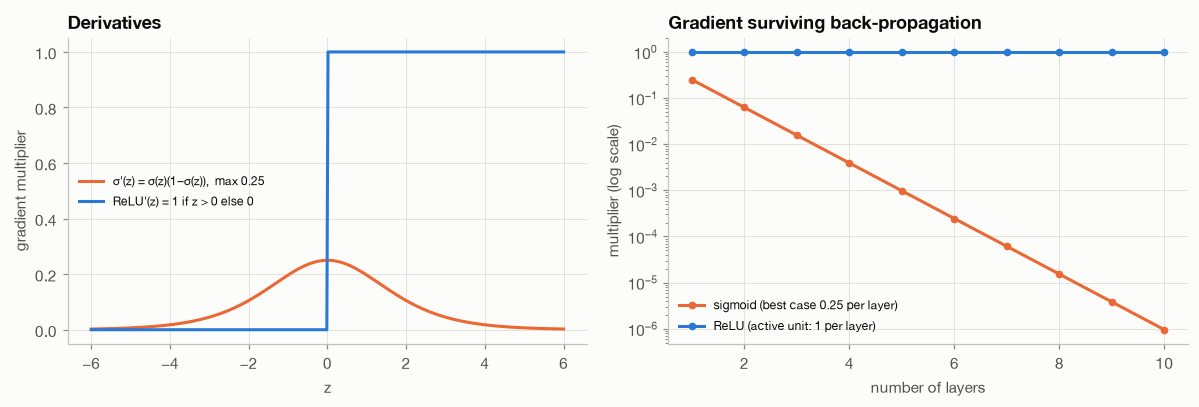

In [9]:
z = np.linspace(-6, 6, 400)
sig = 1 / (1 + np.exp(-z))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(z, sig * (1 - sig), color=P.ORANGE, label="σ'(z) = σ(z)(1−σ(z)),  max 0.25")
axes[0].plot(z, (z > 0).astype(float), color=P.BLUE, label="ReLU'(z) = 1 if z > 0 else 0")
axes[0].set(title='Derivatives', xlabel='z', ylabel='gradient multiplier')
axes[0].legend(fontsize=8, loc='center left')
depth = np.arange(1, 11)
axes[1].semilogy(depth, 0.25 ** depth, color=P.ORANGE, marker='o', markersize=4, label='sigmoid (best case 0.25 per layer)')
axes[1].semilogy(depth, np.ones_like(depth, dtype=float), color=P.BLUE, marker='o', markersize=4, label='ReLU (active unit: 1 per layer)')
axes[1].set(title='Gradient surviving back-propagation', xlabel='number of layers', ylabel='multiplier (log scale)')
axes[1].legend(fontsize=8)
fig.tight_layout()
P.save_figure(fig, config.PLOTS_DIR / 'activation_derivatives.png')
plt.show()

* **Hidden layers → ReLU.** The sigmoid derivative is at most 0.25 and ≈0 once |z| > 4 (saturation). Back-propagation multiplies one such factor per layer, so after 10 sigmoid layers the gradient is ≤ 0.25¹⁰ ≈ 10⁻⁶ — the **vanishing-gradient problem**. ReLU's derivative is exactly 1 for active units, preserving gradient magnitude; it is also cheaper to compute and yields sparse activations.
* **Output → Sigmoid.** The last layer must produce a probability in (0, 1) for BCE and for the cost-threshold sweep, which only the sigmoid provides. Its saturation is harmless here: combined with BCE, the output gradient simplifies to $\hat y - y$ (the σ′ term cancels, exactly as in the perceptron derivation).

## 5 · Record the architecture for the inference API

In [10]:
cfg = config.update_model_config({
    'architecture': {'input_dim': D_in, 'hidden_dims': list(config.HIDDEN_DIMS), 'dropout': config.DROPOUT,
                     'batchnorm': True, 'hidden_activation': 'ReLU', 'output_activation': 'Sigmoid',
                     'trainable_parameters': count_parameters(model)},
    'training': {'optimizer': 'Adam', 'learning_rate': config.LEARNING_RATE,
                 'weight_decay': config.WEIGHT_DECAY, 'batch_size': config.BATCH_SIZE,
                 'max_epochs': config.MAX_EPOCHS, 'patience': config.PATIENCE, 'seed': config.SEED},
})
print('models/model_config.json ->', list(cfg))

models/model_config.json -> ['architecture', 'training', 'imbalance_strategy', 'calibration', 'threshold', 'costs', 'risk_tiers', 'test_metrics']
